In [1]:
import os

print(os.listdir("../data/raw"))

['aa_dataset-tickets-multi-lang-5-2-50-version.csv']


In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/aa_dataset-tickets-multi-lang-5-2-50-version.csv"
)

print(df.shape)

(28587, 16)


Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

print("Libraries loaded successfully")

Libraries loaded successfully


Load Dataset

In [4]:
df = pd.read_csv(
    "../data/raw/aa_dataset-tickets-multi-lang-5-2-50-version.csv"
)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

Dataset Loaded Successfully
Shape: (28587, 16)


Dataset Overview

In [5]:
print("\nRows and Columns")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())


Rows and Columns
(28587, 16)

Columns
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


First Records

In [6]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


Dataset Information

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   24749 non-null  str  
 1   body      28587 non-null  str  
 2   answer    28580 non-null  str  
 3   type      28587 non-null  str  
 4   queue     28587 non-null  str  
 5   priority  28587 non-null  str  
 6   language  28587 non-null  str  
 7   version   28587 non-null  int64
 8   tag_1     28587 non-null  str  
 9   tag_2     28574 non-null  str  
 10  tag_3     28451 non-null  str  
 11  tag_4     25529 non-null  str  
 12  tag_5     14545 non-null  str  
 13  tag_6     5874 non-null   str  
 14  tag_7     2040 non-null   str  
 15  tag_8     565 non-null    str  
dtypes: int64(1), str(15)
memory usage: 3.5 MB


Missing Values

In [8]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

tag_8      28022
tag_7      26547
tag_6      22713
tag_5      14042
subject     3838
tag_4       3058
tag_3        136
tag_2         13
answer         7
dtype: int64

Total Missing Values

In [9]:
print("Total Missing Values:")
print(df.isnull().sum().sum())

Total Missing Values:
98376


Duplicate Records

In [10]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


Language Distribution

In [11]:
df["language"].value_counts()

language
en    16338
de    12249
Name: count, dtype: int64

Language Chart

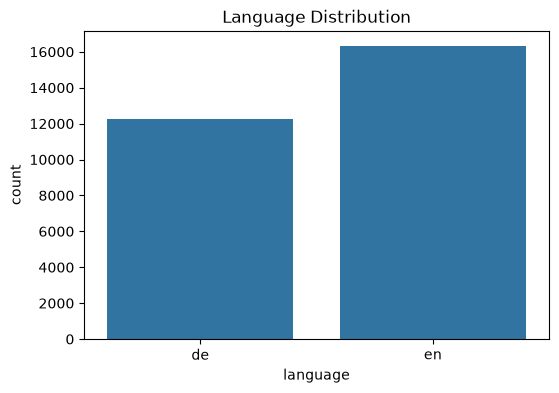

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="language"
)

plt.title("Language Distribution")
plt.show()

Keep English Only

In [13]:
df = df[df["language"] == "en"].copy()

print(df.shape)

(16338, 16)


Queue Distribution

In [14]:
df["queue"].value_counts()

queue
Technical Support                  4737
Product Support                    3073
Customer Service                   2410
IT Support                         1942
Billing and Payments               1595
Returns and Exchanges               820
Service Outages and Maintenance     664
Sales and Pre-Sales                 513
Human Resources                     348
General Inquiry                     236
Name: count, dtype: int64

Queue Chart

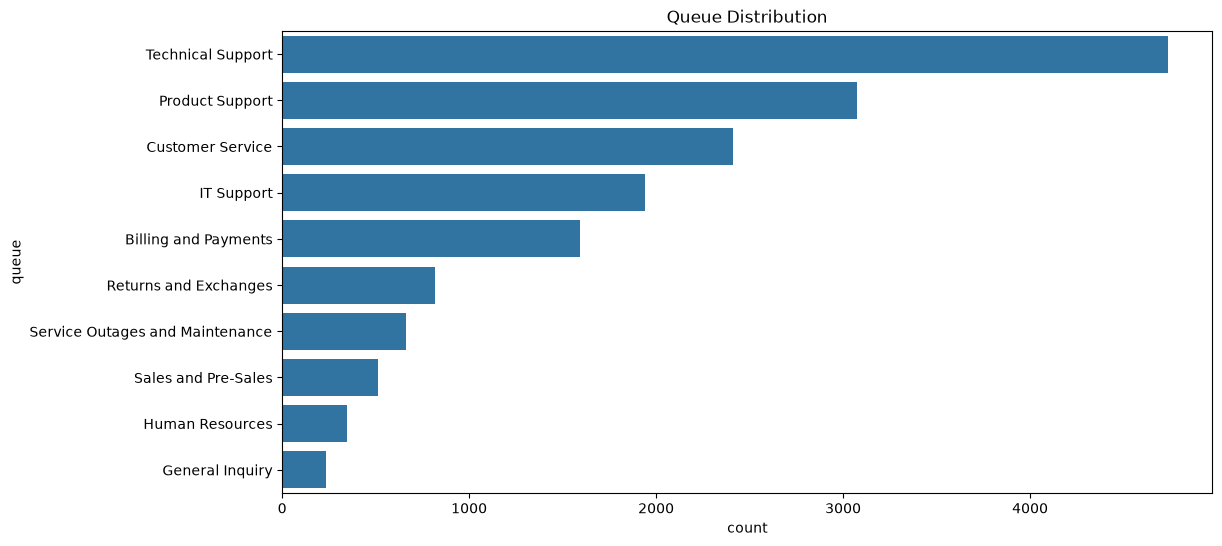

In [15]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="queue",
    order=df["queue"].value_counts().index
)

plt.title("Queue Distribution")
plt.show()

Queue Percentages

In [16]:
round(
    df["queue"].value_counts(normalize=True) * 100,
    2
)

queue
Technical Support                  28.99
Product Support                    18.81
Customer Service                   14.75
IT Support                         11.89
Billing and Payments                9.76
Returns and Exchanges               5.02
Service Outages and Maintenance     4.06
Sales and Pre-Sales                 3.14
Human Resources                     2.13
General Inquiry                     1.44
Name: proportion, dtype: float64

Type Distribution

In [17]:
df["type"].value_counts()

type
Incident    6571
Request     4665
Problem     3397
Change      1705
Name: count, dtype: int64

Type Chart

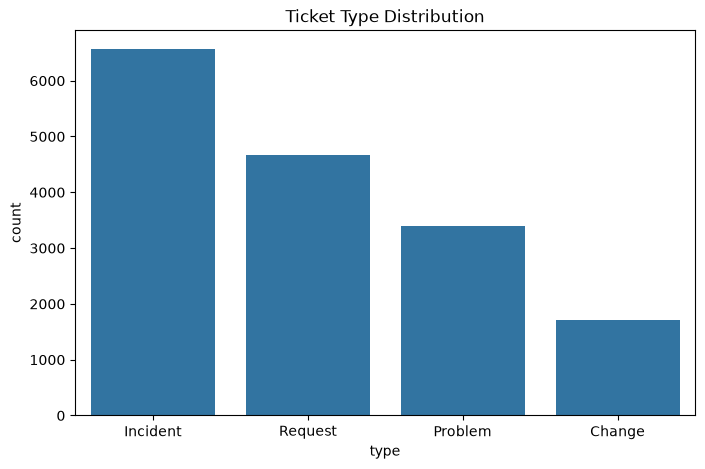

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Ticket Type Distribution")
plt.show()

Priority Distribution

In [19]:
df["priority"].value_counts()

priority
medium    6618
high      6346
low       3374
Name: count, dtype: int64

Priority Chart

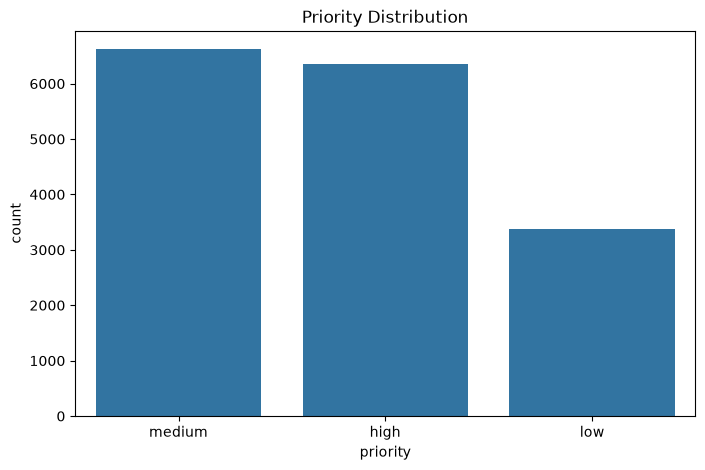

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="priority",
    order=df["priority"].value_counts().index
)

plt.title("Priority Distribution")
plt.show()

Unique Ticket Bodies

In [21]:
print("Unique Ticket Bodies:")
print(df["body"].nunique())

Unique Ticket Bodies:
16338


Subject Examples

In [22]:
df["subject"].sample(10, random_state=42)

25705    Query on Data Analytics Tools for Investment O...
17458                             Problems with Connection
22023                                                  NaN
25800    Found Issues with Secure Data Access in Hospit...
25239                                                  NaN
24919    Review and Update Compatibility Settings for E...
11633         Ensuring Medical Data Security in Healthcare
23015    Query Regarding Digital Strategies in the Digi...
22338    Support Required for Hadoop Integration Troubl...
24273                                                  NaN
Name: subject, dtype: str

Body Examples

In [23]:
df["body"].sample(10, random_state=42)

25705    Dear Customer Support, I am inquiring about th...
17458    Customers are facing occasional connectivity p...
22023    Hello Customer Support, I am inquiring about o...
25800    We have identified secure data access issues w...
25239    Could you offer assistance on securing medical...
24919    Please update the compatibility settings for v...
11633    Inquiring about the security measures in place...
23015    Would you like to know more about our digital ...
22338    An error has occurred during the integration p...
24273    encountered a data breach in hospital systems,...
Name: body, dtype: str

Text Length Analysis

In [27]:
df["text_length"] = (
    df["body"]
    .astype(str)
    .apply(len)
)

Text Length Histogram

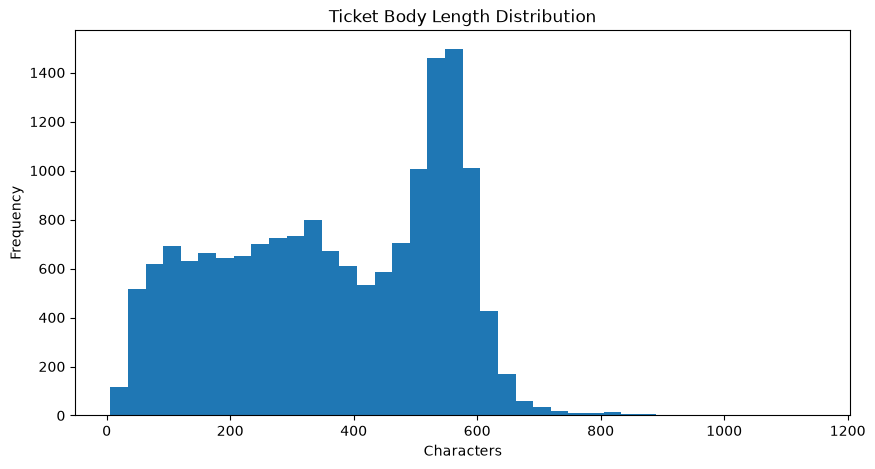

In [28]:
plt.figure(figsize=(10,5))

plt.hist(
    df["text_length"],
    bins=40
)

plt.title("Ticket Body Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

Shortest Tickets

In [31]:
df.sort_values(
    "text_length"
)[
    ["subject", "body", "queue", "text_length"]
].head(5)

,subject,body,queue,text_length
7607,Experiencing Downtime on Multiple Platforms,System,Technical Support,6
1103,Facing System Downtime on Multiple Platforms,Our system,Technical Support,10
13318,Improve medical data security measures,Boost security,Service Outages and Maintenance,14
25844,Boosting Brand Visibility with Digital Marketi...,Support needed.,Human Resources,15
24004,Information on Secure Medical Data Systems,Seeking details,Sales and Pre-Sales,15


Longest Tickets

In [32]:
df.sort_values(
    "text_length",
    ascending=False
)[
    ["subject", "body", "queue", "text_length"]
].head(5)

,subject,body,queue,text_length
6168,Immediate Update Needed for SaaS Platform,"Dear Customer Support,\n\nI am requesting an u...",Customer Service,1147
555,Request for Product Swap,"Dear Customer Support Team,\n\nI am formally r...",Returns and Exchanges,1114
2223,Urgent Update Needed for SaaS Platform,"Dear Customer Support,\n\nI am requesting an u...",Customer Service,1111
389,Request for Complete Product Support Documenta...,"Dear Customer Support Team,\n\nI hope this mes...",Product Support,1087
7298,Assistance Needed with Integration Issue,"Dear Customer Support Team,\n\nI am reporting ...",Billing and Payments,1080


Queue vs Priority

In [33]:
pd.crosstab(
    df["queue"],
    df["priority"]
)

priority,high,low,medium
queue,,,
Billing and Payments,483,342,770
Customer Service,452,837,1121
General Inquiry,38,129,69
Human Resources,35,171,142
IT Support,938,178,826
Product Support,899,599,1575
Returns and Exchanges,185,313,322
Sales and Pre-Sales,88,188,237
Service Outages and Maintenance,467,83,114


Queue vs Type

In [34]:
pd.crosstab(
    df["queue"],
    df["type"]
)

type,Change,Incident,Problem,Request
queue,,,,
Billing and Payments,95,386,344,770
Customer Service,195,607,520,1088
General Inquiry,67,71,49,49
Human Resources,20,184,36,108
IT Support,338,689,490,425
Product Support,350,1383,666,674
Returns and Exchanges,105,319,163,233
Sales and Pre-Sales,90,103,62,258
Service Outages and Maintenance,151,369,44,100


Average Ticket Length by Queue

In [35]:
df.groupby(
    "queue"
)["text_length"].mean().sort_values(ascending=False)

queue
General Inquiry                    396.177966
Technical Support                  372.076842
Customer Service                   369.190456
Product Support                    366.473153
IT Support                         366.217302
Service Outages and Maintenance    365.427711
Sales and Pre-Sales                364.803119
Billing and Payments               363.429467
Returns and Exchanges              360.804878
Human Resources                    350.818966
Name: text_length, dtype: float64

Average Ticket Length Chart

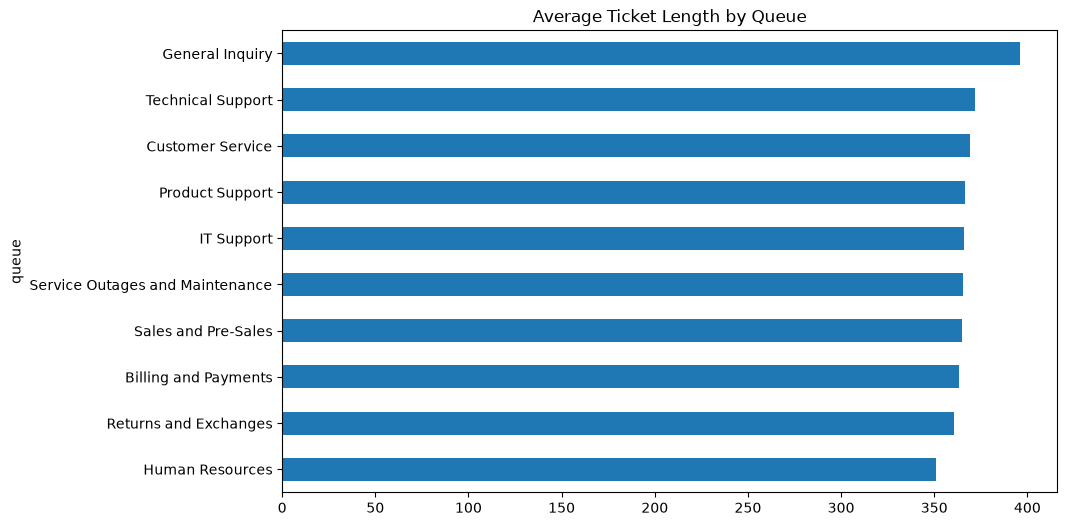

In [36]:
avg_len = (
    df.groupby("queue")["text_length"]
    .mean()
    .sort_values()
)

avg_len.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Average Ticket Length by Queue")
plt.show()

Top Words (Simple)


In [37]:
from collections import Counter
import re

text = " ".join(df["body"].astype(str))

words = re.findall(r"\b[a-zA-Z]{3,}\b", text.lower())

Counter(words).most_common(30)

[('the', 42237),
 ('and', 29969),
 ('you', 11258),
 ('data', 10391),
 ('this', 9172),
 ('for', 8468),
 ('would', 8287),
 ('our', 7755),
 ('your', 7715),
 ('issue', 7383),
 ('have', 7232),
 ('support', 6891),
 ('could', 6769),
 ('with', 6251),
 ('customer', 5726),
 ('assistance', 5652),
 ('are', 5644),
 ('software', 5353),
 ('provide', 5338),
 ('appreciate', 5224),
 ('information', 5135),
 ('that', 4952),
 ('due', 4682),
 ('security', 4515),
 ('please', 4374),
 ('any', 3920),
 ('problem', 3732),
 ('about', 3665),
 ('analytics', 3659),
 ('system', 3659)]

Save Processed Dataset


In [38]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/customer_support_en.csv",
    index=False
)

print("Dataset saved")

Dataset saved


Final EDA Summary

In [39]:
print("FINAL DATASET SUMMARY")
print("-" * 40)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Queues:", df["queue"].nunique())
print("Types:", df["type"].nunique())
print("Priorities:", df["priority"].nunique())
print("Unique Bodies:", df["body"].nunique())
print("Duplicates:", df.duplicated().sum())
print("Missing Values:", df.isnull().sum().sum())

FINAL DATASET SUMMARY
----------------------------------------
Rows: 16338
Columns: 17
Queues: 10
Types: 4
Priorities: 3
Unique Bodies: 16338
Duplicates: 0
Missing Values: 56547


In [40]:
import os

os.path.exists("../data/processed/customer_support_en.csv")

True